# Prac 07.2. Аналіз набору дорожніх знаків GTSRB

## 0. Ознайомлення з набором даних

GTSRB (German Traffic Sign Recognition Benchmark) — набір кольорових
зображень дорожніх знаків для задачі класифікації. Він містить 43 класи.
На кожному зображенні показано один знак, але фотографії відрізняються
розмірами, освітленням і виглядом знака.

## 1. Підготовка даних


In [1]:
import os
import zipfile
import cv2
import numpy as np
import pandas as pd
from collections import Counter
from matplotlib import pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['font.size'] = 11

In [14]:
zip_path = 'archive.zip'
root = 'archive'

print('Архів розпаковується...', flush=True)

with zipfile.ZipFile(zip_path) as dataset_zip:
    dataset_zip.extractall(root)

print('Завершено.')

Архів розпаковується...
Завершено.


## 2. Завантаження і перегляд навчальної вибірки

У `Train.csv` один рядок відповідає одному зображенню.

| Стовпець | Значення |
|---|---|
| `Width`, `Height` | Ширина та висота зображення в пікселях |
| `Roi.X1`, `Roi.Y1`, `Roi.X2`, `Roi.Y2` | Координати прямокутної області знака |
| `ClassId` | Номер класу дорожнього знака |


In [15]:
data = pd.read_csv(os.path.join(root, 'Train.csv'))

num_samples = len(data)
num_classes = data['ClassId'].nunique()

print('Кількість навчальних зображень:', num_samples)
print('Кількість класів:', num_classes)
print('Пропусків у таблиці:', data.isna().sum().sum())
data.head()

Кількість навчальних зображень: 39209
Кількість класів: 43
Пропусків у таблиці: 0


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


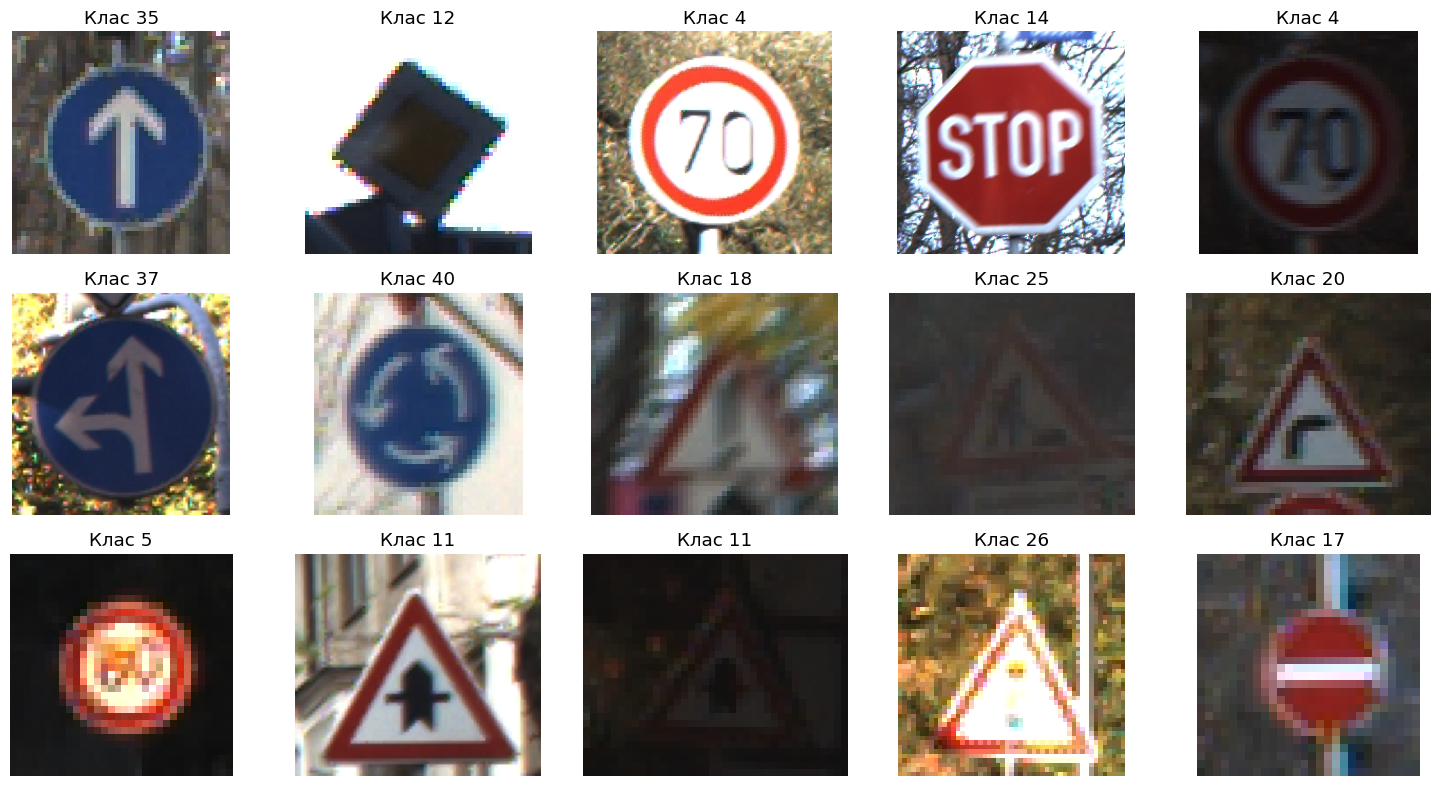

In [16]:
indices = np.random.choice(num_samples, 15, replace=False)

plt.figure(figsize=(15, 8))
for ii, idx in enumerate(indices):
    row = data.iloc[idx]
    path = os.path.join(root, row['Path'])
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 5, ii + 1)
    plt.imshow(img)
    plt.title(f"Клас {row['ClassId']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Розподіл зображень за класами

За допомогою `Counter` підраховую, скільки разів зустрічається кожен
`ClassId`. На діаграмі пунктиром показую кількість зображень, яку мав би
кожен клас за рівномірного розподілу.

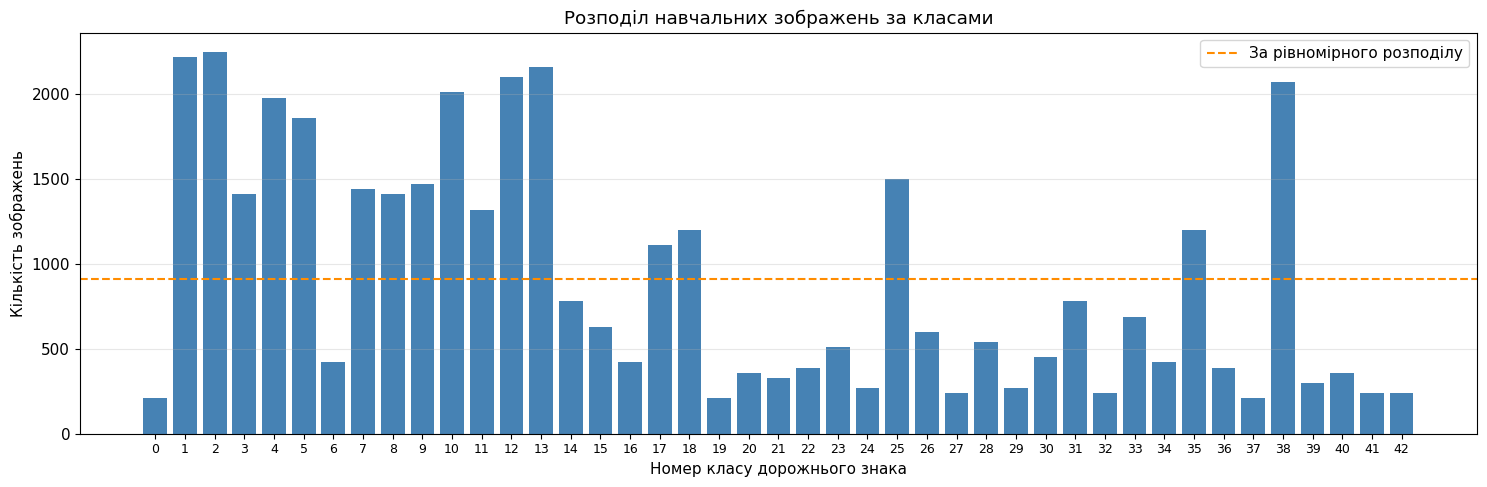

In [17]:
ids = data['ClassId'].to_numpy()
hist = Counter(ids)
class_ids = sorted(hist)
class_counts = [hist[class_id] for class_id in class_ids]

plt.bar(class_ids, class_counts, color='steelblue')
plt.axhline(num_samples / num_classes, color='darkorange', linestyle='--',
            label='За рівномірного розподілу')
plt.xticks(class_ids, fontsize=9)
plt.xlabel('Номер класу дорожнього знака')
plt.ylabel('Кількість зображень')
plt.title('Розподіл навчальних зображень за класами')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
class_table = pd.DataFrame({
    'ClassId': class_ids,
    'Count': class_counts
})
class_table['Share (%)'] = 100 * class_table['Count'] / num_samples
class_table = class_table.sort_values(['Count', 'ClassId'], ascending=[False, True])

print('П’ять найчисленніших класів:')
display(class_table.head(5).round(2).reset_index(drop=True))
print('П’ять найменш численних класів:')
display(class_table.tail(5).sort_values(['Count', 'ClassId']).round(2).reset_index(drop=True))
print('Відношення найбільшої кількості до найменшої:',
      round(max(class_counts) / min(class_counts), 2))

П’ять найчисленніших класів:


,ClassId,Count,Share (%)
0,2,2250,5.74
1,1,2220,5.66
2,13,2160,5.51
3,12,2100,5.36
4,38,2070,5.28


П’ять найменш численних класів:


,ClassId,Count,Share (%)
0,0,210,0.54
1,19,210,0.54
2,37,210,0.54
3,41,240,0.61
4,42,240,0.61


Відношення найбільшої кількості до найменшої: 10.71


## 4. Додатковий аналіз: розміри зображень

Використовую ширину та висоту з `Train.csv`. Також обчислюю кількість
пікселів як добуток ширини на висоту, щоб оцінити розмір зображення загалом.

In [19]:
data['Pixels'] = data['Width'] * data['Height']
data[['Width', 'Height', 'Pixels']].describe().round(2)

,Width,Height,Pixels
count,39209.00,39209.00,39209.00
mean,50.84,50.33,3109.83
std,24.31,23.12,3664.55
min,25.00,25.00,625.00
25%,35.00,35.00,1190.00
50%,43.00,43.00,1849.00
75%,58.00,58.00,3360.00
max,243.00,225.00,54675.00


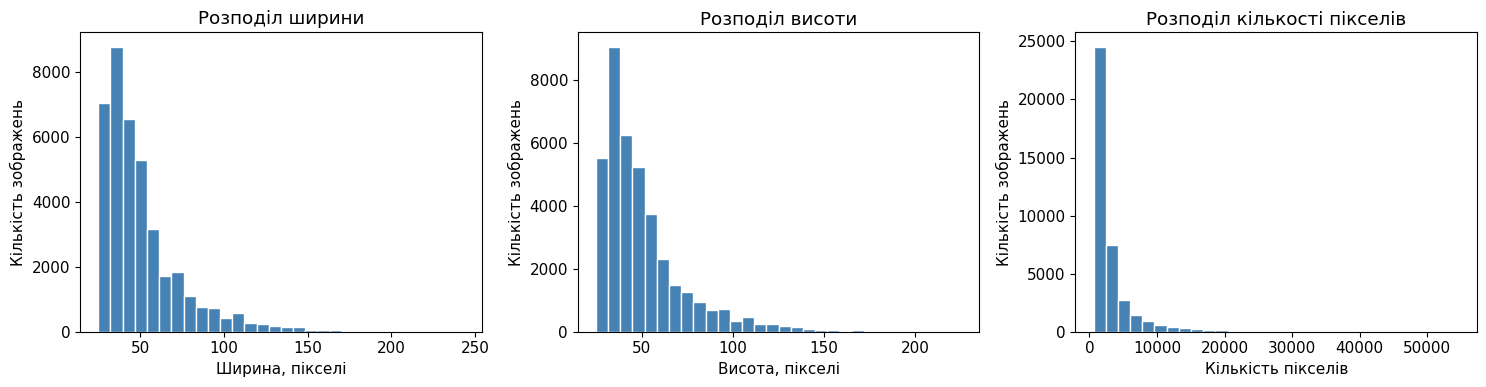

Зображень із шириною та висотою не більше 64 пікселів: 80.23%


In [20]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(data['Width'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Ширина, пікселі')
plt.ylabel('Кількість зображень')
plt.title('Розподіл ширини')

plt.subplot(1, 3, 2)
plt.hist(data['Height'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Висота, пікселі')
plt.ylabel('Кількість зображень')
plt.title('Розподіл висоти')

plt.subplot(1, 3, 3)
plt.hist(data['Pixels'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Кількість пікселів')
plt.ylabel('Кількість зображень')
plt.title('Розподіл кількості пікселів')

plt.tight_layout()
plt.show()

small_share = 100 * ((data['Width'] <= 64) & (data['Height'] <= 64)).mean()
print(f'Зображень із шириною та висотою не більше 64 пікселів: {small_share:.2f}%')

## 5. Додатковий аналіз: яскравість зображень

Для кожного навчального зображення обчислюю середнє значення пікселів
після перетворення у відтінки сірого. Значення близько 0 відповідає темному
зображенню, а близько 255 — світлому. 

In [21]:
brightness = []

for path in data['Path']:
    full_path = os.path.join(root, path)
    img = cv2.imread(full_path)
    if img is None:
        raise FileNotFoundError(full_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness.append(gray.mean())

data['Brightness'] = brightness
print('Оброблено зображень:', len(brightness))
data['Brightness'].describe().round(2)

Оброблено зображень: 39209


count    39209.00
mean        82.01
std         47.64
min          6.20
25%         43.72
50%         74.35
75%        113.64
max        248.44
Name: Brightness, dtype: float64

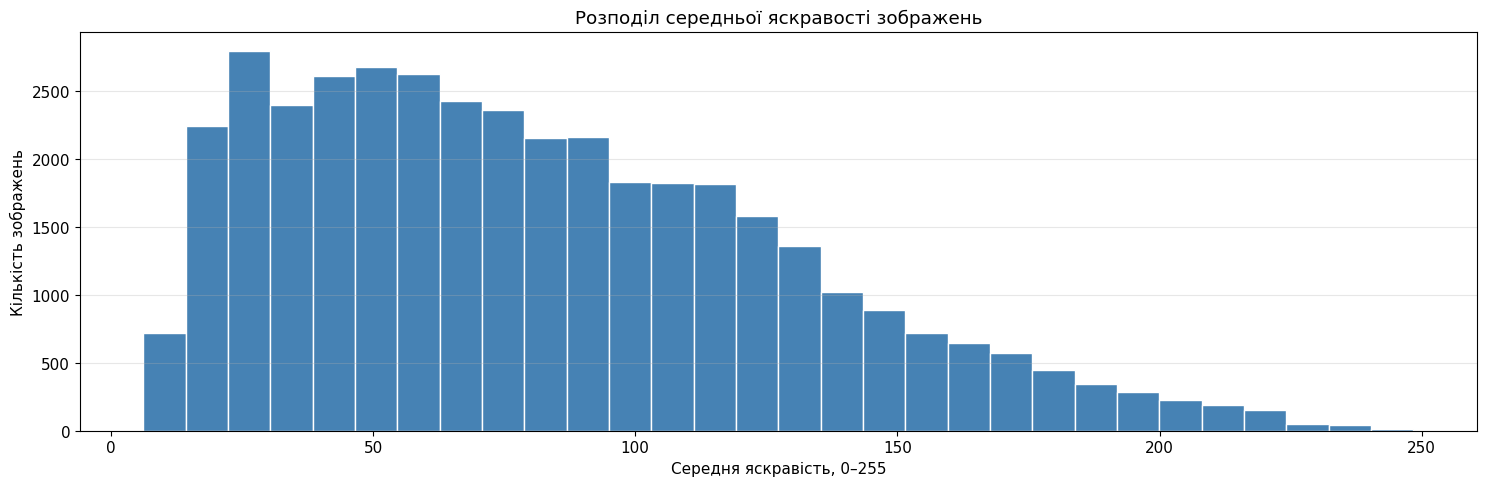

In [22]:
plt.hist(data['Brightness'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Середня яскравість, 0–255')
plt.ylabel('Кількість зображень')
plt.title('Розподіл середньої яскравості зображень')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

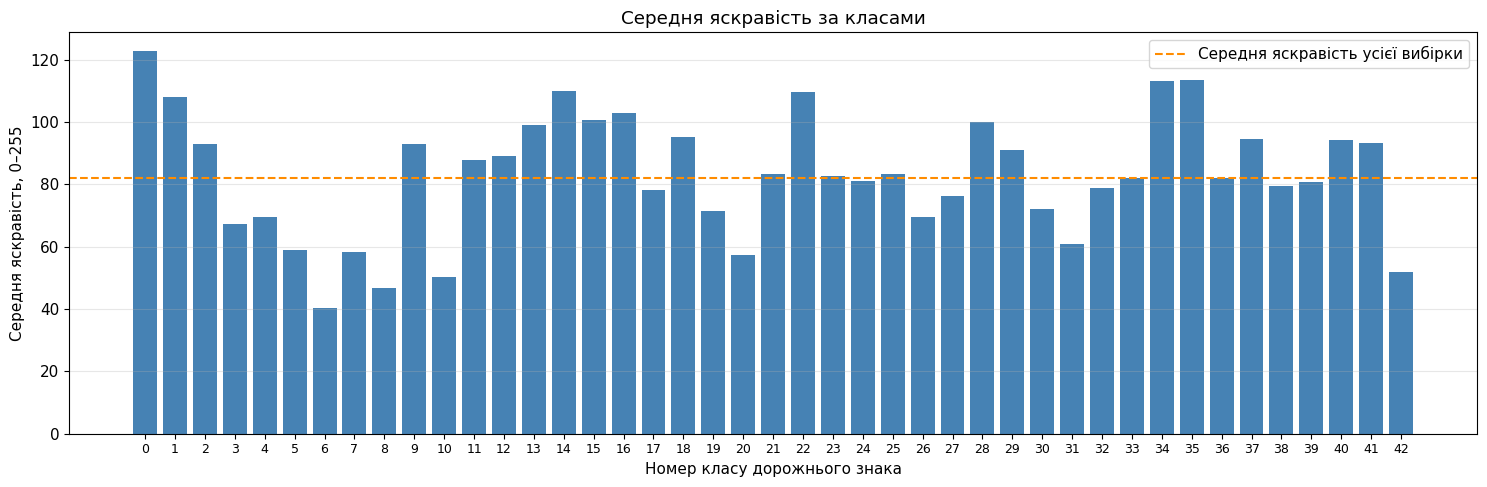

П’ять найсвітліших у середньому класів:


,Mean brightness
ClassId,
0,122.70
35,113.53
34,113.34
14,110.13
22,109.75


П’ять найтемніших у середньому класів:


,Mean brightness
ClassId,
6,40.25
8,46.91
10,50.39
42,52.03
20,57.36


In [23]:
class_brightness = data.groupby('ClassId')['Brightness'].mean()

plt.bar(class_brightness.index, class_brightness.values, color='steelblue')
plt.axhline(data['Brightness'].mean(), color='darkorange', linestyle='--',
            label='Середня яскравість усієї вибірки')
plt.xticks(class_brightness.index, fontsize=9)
plt.xlabel('Номер класу дорожнього знака')
plt.ylabel('Середня яскравість, 0–255')
plt.title('Середня яскравість за класами')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

brightness_table = class_brightness.rename('Mean brightness').to_frame()
print('П’ять найсвітліших у середньому класів:')
display(brightness_table.sort_values('Mean brightness', ascending=False).head(5).round(2))
print('П’ять найтемніших у середньому класів:')
display(brightness_table.sort_values('Mean brightness').head(5).round(2))